## Notebook for generating the overlap of genome wide TFBS and our elements

In [1]:
remap_with_combined_TFBS = "/sc-projects/sc-proj-bih-reg-seqs/users/kisa11/projects/80k_remap2022_overlap/remap2022_nr_macs2_hg38_v1_0_target_column.bed.gz"
all_tested_CRE_bed = "/sc-projects/sc-proj-bih-reg-seqs/users/kisa11/projects/80k_remap2022_overlap/CREs_all_tested.bed.gz"

get the target column: 
awk 'BEGIN{OFS="\t"} {$NF=$NF; split($4,a,":"); print $0, a[1]}' <(zcat remap2022_nr_macs2_hg38_v1_0.bed.gz) | gzip > remap2022_nr_macs2_hg38_v1_0_target_column.bed.gz

sort the remap file: 
sort -k1,1 -k2,2n <( zcat remap2022_nr_macs2_hg38_v1_0_target_column.bed.gz ) | gzip > remap2022_nr_macs2_hg38_v1_0_target_column_sorted.bed.gz

Start bedtools intersect on the charite cluster
-wo for having the overlap size in the output

bedtools intersect -a /sc-projects/sc-proj-bih-reg-seqs/users/kisa11/projects/80k_remap2022_overlap/all_tested_CRE_sorted.bed.gz -b /sc-projects/sc-proj-bih-reg-seqs/users/kisa11/projects/80k_remap2022_overlap/remap2022_nr_macs2_hg38_v1_0_target_column_sorted.bed.gz -wo > tested_CREs_remap2022.bed.gz

### Load the overlap file: 

In [2]:
import ast
import sys
import pandas as pd
import numpy as np # For potential NaN handling if needed
import os


sys.path.append('../../00_helpful_functions')
import helpful_functions as hf
# from importlib import reload
# reload(hf)

# column names
col_name = 'name'
col_header = 'name'
col_sequence = 'sequence'
col_category = 'category'
col_class = 'class'
col_source = 'source'
col_ref = 'ref'
col_chr = 'chr'
col_start = 'start'
col_end = 'end'
col_strand = 'strand'
col_variant_class = 'variant_class'
col_variant_pos = 'variant_pos'
col_SPDI = 'SPDI'
col_allele = 'allele'
col_info = 'info'


list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]

# Function to safely evaluate string representations of lists
def safe_eval(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x


import yaml

config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

In [3]:
remap2022_CRE_overlap_path = "/home/kisa/coding/80K_MPRA/remap_chipseq_pia/remap_cre_overlap/tested_CREs_remap2022.bed.gz"
remap2022_CRE_overlap = pd.read_csv(remap2022_CRE_overlap_path, sep="\t", header=None, low_memory=False)
remap2022_CRE_overlap.columns = ["chrom", "start", "end", "name", "score", "strand", "chrom_B", "start_B", "end_B", "name_remap", "score_B", "strand_B", "peak_start", "peak_end", "spectrum", "TF_name", "overlap_number"]

# remap2022_CRE_overlap["target_column"] = remap2022_CRE_overlap["target_column"].str.split(":").str[0]

In [4]:
remap2022_CRE_overlap

,chrom,start,end,name,score,strand,chrom_B,start_B,end_B,name_remap,score_B,strand_B,peak_start,peak_end,spectrum,TF_name,overlap_number
0,chr1,2179507,2179777,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0,+,chr1,2179115,2180431,HDAC8:K-562,1,.,2179849,2179850,"56,112,168",HDAC8,270
1,chr1,2179507,2179777,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0,+,chr1,2179168,2179769,"MITF:501-mel,melanocyte,K-562",6,.,2179468,2179469,"196,168,168",MITF,262
2,chr1,2179507,2179777,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0,+,chr1,2179172,2179873,RBBP4:SCMC,1,.,2179508,2179509,"19,253,196",RBBP4,270
3,chr1,2179507,2179777,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0,+,chr1,2179188,2180104,KLF17:HEK293,1,.,2179641,2179642,"119,23,81",KLF17,270
4,chr1,2179507,2179777,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0,+,chr1,2179248,2180076,HDGF:K-562,1,.,2179883,2179884,"112,84,224",HDGF,270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3344101,chrX,154552145,154552415,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,0,-,chrX,154552191,154552561,ESR1:T-47D,2,.,154552420,154552421,"224,168,84",ESR1,224
3344102,chrX,154552145,154552415,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,0,-,chrX,154552215,154552416,MYC:P493-6,1,.,154552312,154552313,"56,28,56",MYC,200
3344103,chrX,154552145,154552415,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,0,-,chrX,154552220,154552401,"SPI1:primary-monocyte,monocyte,primary-neutrop...",9,.,154552307,154552308,"252,28,112",SPI1,181
3344104,chrX,154552145,154552415,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,0,-,chrX,154552279,154552371,GATA6:AGS,1,.,154552344,154552345,"224,224,224",GATA6,92


#### Investigate the dataset
- How many different TFs are there? 1179 different but over 3x10^6 different overlaps
- How many CREs are there? 
- How large is the overlap generally? (what is max and min?) => Should I use a proportion based on the CRE length?
- from 1 to 270 so I should at least see an overlap of 0.1 so 27bp of the CRE and I should filter that the peak is not directly at the start or the end of the CRE because these positions will be lost anyways in the MPRA because of different contexts

In [5]:
remap2022_CRE_overlap["TF_name"].nunique() # 1179


1179

<Axes: >

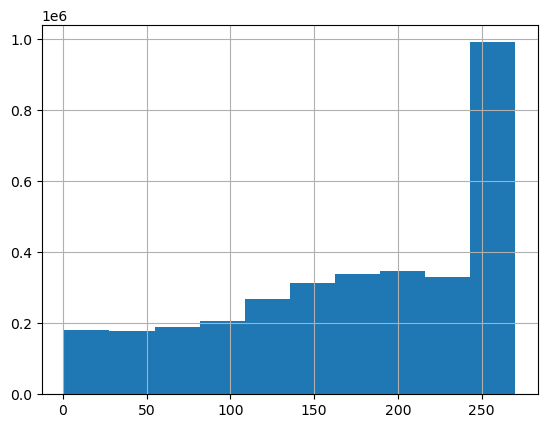

In [6]:
remap2022_CRE_overlap["overlap_number"].hist()

In [7]:
remap2022_CRE_overlap["overlap_number"].describe()

count    3.344106e+06
mean     1.769143e+02
std      8.114687e+01
min      1.000000e+00
25%      1.170000e+02
50%      1.890000e+02
75%      2.570000e+02
max      2.700000e+02
Name: overlap_number, dtype: float64

In [8]:
# investigate the size of the overlapping TFBS peaks
remap2022_CRE_overlap["chip_peak_size"] = remap2022_CRE_overlap["end_B"] - remap2022_CRE_overlap["start_B"]

<Axes: >

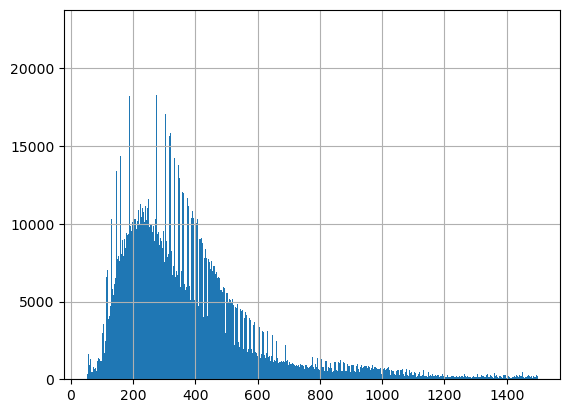

In [9]:
remap2022_CRE_overlap["chip_peak_size"].hist(bins=1000)

In [10]:
remap2022_CRE_overlap.shape[0]

3344106

In [19]:
CRE_LENGTH = 270
remap2022_CRE_overlap["CRE_proportion_overlapped"] = round(remap2022_CRE_overlap["overlap_number"] / (CRE_LENGTH)*100, 2)

In [20]:
# how many chip-seq peaks are over 270bp: 57% of the 3300000
round(remap2022_CRE_overlap[remap2022_CRE_overlap["chip_peak_size"] > 270].shape[0] / remap2022_CRE_overlap.shape[0] * 100, 2)

57.86

In [21]:
long_chip_peaks = remap2022_CRE_overlap[remap2022_CRE_overlap["chip_peak_size"] > 270].copy()


In [22]:
# check for the small peaks how their overlap proportion looks like
small_chip_peaks = remap2022_CRE_overlap[remap2022_CRE_overlap["chip_peak_size"] <= 270].copy()
small_chip_peaks

,chrom,start,end,name,score,strand,chrom_B,start_B,end_B,name_remap,score_B,strand_B,peak_start,peak_end,spectrum,TF_name,overlap_number,chip_peak_size,CRE_proportion_overlapped
5,chr1,2179507,2179777,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0,+,chr1,2179262,2179518,CBX2:HEK293T,1,.,2179442,2179443,"28,168,196",CBX2,11,256,4.07
9,chr1,2179507,2179777,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0,+,chr1,2179342,2179612,"USF2:GM12878,K-562",4,.,2179444,2179445,"252,224,168",USF2,105,270,38.89
18,chr1,2179507,2179777,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0,+,chr1,2179439,2179632,CBFA2T2:K-562,1,.,2179579,2179580,"112,28,84",CBFA2T2,125,193,46.30
25,chr1,2179507,2179777,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0,+,chr1,2179466,2179709,ZNF281:K-562,1,.,2179599,2179600,"113,221,136",ZNF281,202,243,74.81
26,chr1,2179507,2179777,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0,+,chr1,2179470,2179625,ASCL1:SCLC,1,.,2179571,2179572,"140,84,112",ASCL1,118,155,43.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3344100,chrX,154552145,154552415,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,0,-,chrX,154552171,154552396,"ELF1:K-562,GM12878",2,.,154552251,154552252,"140,140,224",ELF1,225,225,83.33
3344102,chrX,154552145,154552415,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,0,-,chrX,154552215,154552416,MYC:P493-6,1,.,154552312,154552313,"56,28,56",MYC,200,201,74.07
3344103,chrX,154552145,154552415,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,0,-,chrX,154552220,154552401,"SPI1:primary-monocyte,monocyte,primary-neutrop...",9,.,154552307,154552308,"252,28,112",SPI1,181,181,67.04
3344104,chrX,154552145,154552415,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,0,-,chrX,154552279,154552371,GATA6:AGS,1,.,154552344,154552345,"224,224,224",GATA6,92,92,34.07


<Axes: >

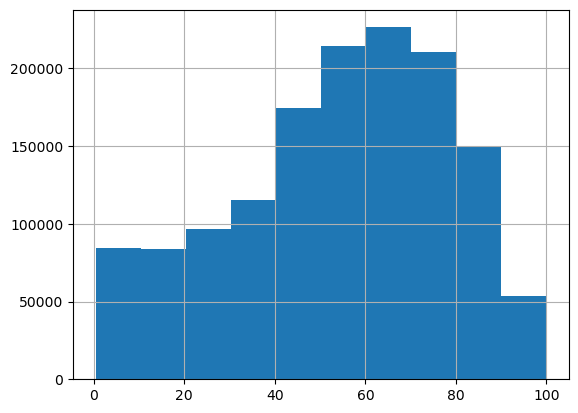

In [23]:
small_chip_peaks["CRE_proportion_overlapped"].hist()

<Axes: >

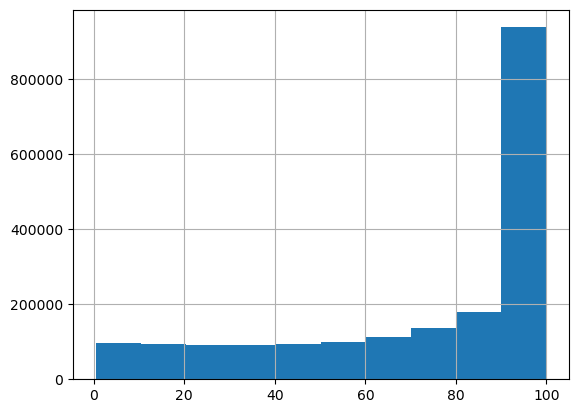

In [24]:
long_chip_peaks["CRE_proportion_overlapped"].hist()

In [25]:
# check the distance to the peak start and end to the CRE start and end
start_difference = remap2022_CRE_overlap["start_B"] - remap2022_CRE_overlap["start"]
# do I see negative values?
start_difference.describe()


count    3.344106e+06
mean    -4.742637e+01
std      2.021956e+02
min     -1.498000e+03
25%     -1.250000e+02
50%     -1.200000e+01
75%      7.300000e+01
max      2.690000e+02
dtype: float64

In [26]:
summit_size = remap2022_CRE_overlap["peak_end"] - remap2022_CRE_overlap["peak_start"]
summit_size.describe()

count    3344106.0
mean           1.0
std            0.0
min            1.0
25%            1.0
50%            1.0
75%            1.0
max            1.0
dtype: float64

##### Filter the dataset based on the overlap of the summit
- Note: not all peaks are longer than 270bp
- Filter for summit should overlap the CREs but not the edges and at least 10 bp should be overlapping

<Axes: >

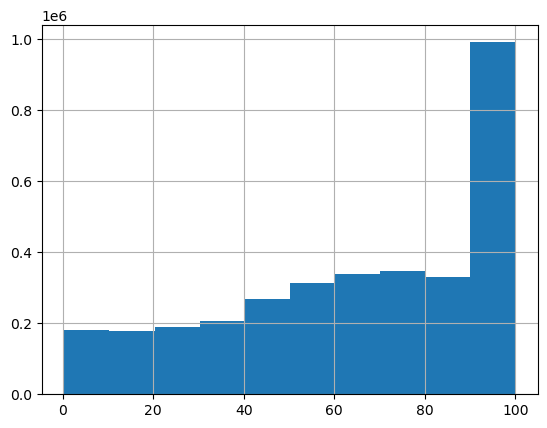

In [27]:
remap2022_CRE_overlap["CRE_proportion_overlapped"].hist()

In [28]:
remap2022_CRE_overlap.shape[0]

3344106

In [29]:
overlap_threshold = 0.1

In [30]:
remap2022_CRE_overlap.columns

Index(['chrom', 'start', 'end', 'name', 'score', 'strand', 'chrom_B',
       'start_B', 'end_B', 'name_remap', 'score_B', 'strand_B', 'peak_start',
       'peak_end', 'spectrum', 'TF_name', 'overlap_number', 'chip_peak_size',
       'CRE_proportion_overlapped'],
      dtype='object')

In [31]:
remap2022_CRE_overlap_filtered_df = remap2022_CRE_overlap[
    (remap2022_CRE_overlap['peak_start'] >= remap2022_CRE_overlap['start'] + 5) &
    (remap2022_CRE_overlap['peak_end'] <= remap2022_CRE_overlap['end'] - 5)  &
    (remap2022_CRE_overlap['overlap_number'] >= 10)
]

# remap2022_CRE_overlap_filtered_df = remap2022_CRE_overlap[
#     (remap2022_CRE_overlap['peak_start'] >= remap2022_CRE_overlap['start']) &
#     (remap2022_CRE_overlap['peak_end'] <= remap2022_CRE_overlap['end'])
# ]
print(f"Number of interactions after summit filtering: {len(remap2022_CRE_overlap_filtered_df)}")
print(f"Proportion of interactions after summit filtering: {len(remap2022_CRE_overlap_filtered_df)/len(remap2022_CRE_overlap)}")


Number of interactions after summit filtering: 2162028
Proportion of interactions after summit filtering: 0.6465189799605634


In [32]:
remap2022_CRE_overlap_filtered_df["CRE_proportion_overlapped"].describe()
# remap2022_CRE_overlap_filtered_df["CRE_proportion_overlapped"].hist()

count    2.162028e+06
mean     7.752747e+01
std      2.094071e+01
min      3.700000e+00
25%      6.185000e+01
50%      8.074000e+01
75%      1.000000e+02
max      1.000000e+02
Name: CRE_proportion_overlapped, dtype: float64

##### Investigate the number of TFBS overlapping CREs
- How many TFBS overlap with at least one CRE?
- ~2.8k sequences are not overlapping with any CREs

In [33]:
remap2022_CRE_overlap_filtered_df["TF_name"].nunique() # 1153


1153

In [34]:
# How many CREs are overlapped by at least one TFBS?
remap2022_CRE_overlap_filtered_df["name"].nunique() # 65565 (initially: 68241)

65565

count    65565.000000
mean        32.975337
std         42.604681
min          1.000000
25%          7.000000
50%         17.000000
75%         41.000000
max        392.000000
Name: count, dtype: float64

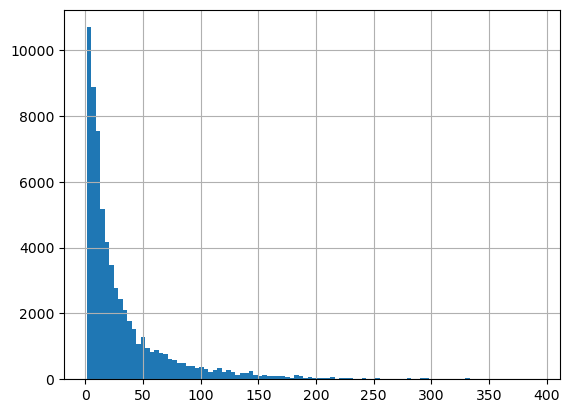

In [35]:
# number of TFBS overlapping with CREs:
number_of_tfbs_per_CRE = remap2022_CRE_overlap_filtered_df["name"].value_counts().reset_index()
number_of_tfbs_per_CRE

number_of_tfbs_per_CRE["count"].hist(bins=100)

number_of_tfbs_per_CRE["count"].describe() # some sequences only have 1 TFBS overlapping some sequences have 392 overlapping but median is 41

In [46]:
remap2022_CRE_overlap_filtered_df.columns

Index(['chrom', 'start', 'end', 'name', 'score', 'strand', 'chrom_B',
       'start_B', 'end_B', 'name_remap', 'score_B', 'strand_B', 'peak_start',
       'peak_end', 'spectrum', 'TF_name', 'overlap_number', 'chip_peak_size',
       'CRE_proportion_overlapped'],
      dtype='object')

In [47]:
# write the filtered remap overlap:
output_path = "/home/kisa/coding/80K_MPRA/remap_chipseq_pia/remap_cre_overlap/tested_CREs_remap2022_filtered_summit_overlap_no_border_overlap_min_10bp.bed.gz"
writing = False
if writing:
    remap2022_CRE_overlap_filtered_df.to_csv(output_path, sep="\t", index=False)


In [ ]:
# all combined in one code block:
run it only when you are aware of it
import pandas as pd
import matplotlib.pyplot as plt

remap2022_CRE_overlap_path = "/sc-projects/sc-proj-bih-reg-seqs/users/kisa11/projects/80k_remap2022_overlap/all_SCREEN_CREs_remap2022.bed"
remap2022_CRE_overlap = pd.read_csv(remap2022_CRE_overlap_path, sep="\t", header=None, low_memory=False)
remap2022_CRE_overlap.columns = ["chrom", "start", "end", "name", "score", "strand", "chrom_B", "start_B", "end_B", "name_remap", "score_B", "strand_B", "peak_start", "peak_end", "spectrum", "TF_name", "overlap_number"]


remap2022_CRE_overlap["overlap_number"].hist()

remap2022_CRE_overlap_filtered_df = remap2022_CRE_overlap[
    (remap2022_CRE_overlap['peak_start'] >= remap2022_CRE_overlap['start'] + 5) &
    (remap2022_CRE_overlap['peak_end'] <= remap2022_CRE_overlap['end'] - 5)  &
    (remap2022_CRE_overlap['overlap_number'] >= 10)
]

print(f"Number of interactions after summit filtering: {len(remap2022_CRE_overlap_filtered_df)}")
print(f"Proportion of interactions after summit filtering: {len(remap2022_CRE_overlap_filtered_df)/len(remap2022_CRE_overlap)}")

# write the filtered remap overlap:
output_path = "all_SCREE_CREs_remap2022_filtered_summit_overlap_no_border_overlap_min_10bp.bed.gz"
writing = True
if writing:
    remap2022_CRE_overlap_filtered_df[["chrom", "start", "end", "name", "score", "strand", "name_remap", "TF_name", "overlap_number"]].to_csv(output_path, sep="\t", index=False)


#### Annotate the sequences with activity and the gene information

In [36]:
metadata_80k = pd.read_csv(config["files"]["creating"]["metadata_final_20250707"], sep="\t", low_memory=False)


In [37]:
metadata_80k

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info
0,GC_Mohlke:REF_NC000001.11|159752292|A|G|Mohlke...,ATACATCCTTTAATTTGTTCCTACATCTTGCTTGGATTTTCCCCTG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,159752058.0,159752328.0,+,"[""SNV""]",[234],"[""NC_000001.11:159752292:A:G""]","[""ref""]",NaN
1,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,TGTGTCTGGTGAGGTTGCTGACACTGCTTTTGGATGAGAGAGAGAG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159023.0,230159293.0,+,"[""SNV""]",[145],"[""NC_000001.11:230159168:C:T""]","[""ref""]",NaN
2,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,"[""SNV"", ""indel""]","[32, 192]","[""NC_000001.11:230159168:C:T"", ""NC_000001.11:2...","[""ref"", ""ref""]",NaN
3,GC_Mohlke:ALT_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,"[""indel""]",[192],"[""NC_000001.11:230159328:TCTTAAAGTGTTCAGCACTCC...","[""alt""]",NaN
4,GC_Mohlke:REF_NC000001.11|230161389|C|T|Mohlke...,CCTCAACTCTCCACATGCCCCAGTAGCATAGACCAGCTTCCTTACA...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230161269.0,230161539.0,+,"[""SNV""]",[120],"[""NC_000001.11:230161389:C:T""]","[""ref""]",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80210,GC_Glut_Chengyu:Glut|chr7:31260964-31261233|+|...,TTTCTTATACTGTATGTTTAAAGATATAGACAATGCATATACAAGT...,element,element inactive control,NaN,GRCh38,chr7,31260963.0,31261233.0,NaN,NaN,NaN,NaN,NaN,NaN
80211,C_negative_neuron_MK:tile_8033_chr11_69157415_...,TTTGCAGATTACGTCAGCGCTGGCGAGCAGGGGGCGCGGGGACAGC...,element,element inactive control,Michael Kosicki,GRCh38,chr11,69157414.0,69157684.0,+,NaN,NaN,NaN,NaN,NaN
80212,C_negative_neuron_MK:tile_22216_chr2_85772228_...,TTTGTGCCGCCGGCGAGGACTGACACCAGGTTAAGTCGCCTGGCGG...,element,element inactive control,Michael Kosicki,GRCh38,chr2,85772227.0,85772497.0,+,NaN,NaN,NaN,NaN,NaN
80213,C_positive_neuron_MK:tile_37243_chr6_97306567_...,TTTTTATTGTACTAATCAGTCTCAAGATGTTCTCTGTGTTAATTGG...,variant,variant positive control,Michael Kosicki,GRCh38,chr6,97306566.0,97306836.0,+,"[""SNV""]",[244],"[""NC_000006.12:97306810:G:C""]","[""alt""]",NaN


In [38]:
metadata_path = config["files"]["creating"]["metadata_final_20250707"]
metadata_80k = pd.read_csv(metadata_path, sep="\t", low_memory=False)

# write design file as fasta:


In [39]:
NGN2_element_activity = pd.read_csv(config["files"]["creating"]["NGN2_element_metadata_with_bcalm_2025_04_bbmap_normalized_counts_scrambled"], sep="\t", low_memory=False)
NGN2_element_activity

,name,sequence,category,class,source,ref,chr,start,end,strand,...,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl
0,GC_Mohlke:REF_NC000001.11|159752292|A|G|Mohlke...,ATACATCCTTTAATTTGTTCCTACATCTTGCTTGGATTTTCCCCTG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,159752058.0,159752328.0,+,...,['NC_000001.11:159752292:A:G'],['ref'],NaN,1.000000e+00,0.002170,True,GC_Mohlke,0.002170,2.425938,0.447914
1,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,TGTGTCTGGTGAGGTTGCTGACACTGCTTTTGGATGAGAGAGAGAG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159023.0,230159293.0,+,...,['NC_000001.11:230159168:C:T'],['ref'],NaN,1.000000e+00,-0.005898,True,GC_Mohlke,-0.005898,2.197536,0.239294
2,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,"['NC_000001.11:230159168:C:T', 'NC_000001.11:2...","['ref', 'ref']",NaN,1.000000e+00,0.005348,True,GC_Mohlke,0.005348,2.515917,0.530100
3,GC_Mohlke:ALT_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,['NC_000001.11:230159328:TCTTAAAGTGTTCAGCACTCC...,['alt'],NaN,1.000000e+00,-0.007093,True,GC_Mohlke,-0.007093,2.163688,0.208377
4,GC_Mohlke:REF_NC000001.11|230161389|C|T|Mohlke...,CCTCAACTCTCCACATGCCCCAGTAGCATAGACCAGCTTCCTTACA...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230161269.0,230161539.0,+,...,['NC_000001.11:230161389:C:T'],['ref'],NaN,1.332728e-33,0.184521,True,GC_Mohlke,0.184521,7.588730,5.163559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80210,GC_Glut_Chengyu:Glut|chr12:44940899-44941168|-...,TGTCCAAAAAAAGTAAAAGTCATAACAGAAATTGGATTTCAAATGG...,element,element inactive control,NaN,GRCh38,chr12,44940898.0,44941168.0,-,...,NaN,NaN,NaN,1.000000e+00,-0.007241,True,GC_Glut_Chengyu,-0.007241,2.159500,0.204552
80211,GC_Glut_Chengyu:Glut|chr2:212699381-212699650|...,TGTGAGTGCTATAATTGTAACCCTTTATAATTGACAGACATTAATT...,element,element inactive control,NaN,GRCh38,chr2,212699380.0,212699650.0,+,...,NaN,NaN,NaN,1.000000e+00,0.030434,True,GC_Glut_Chengyu,0.030434,3.226171,1.178839
80212,GC_Glut_Chengyu:Glut|chr10:26798829-26799098|-...,TTTAATAGGAGTACTATTGAATTTACATTTAATGTAGTTAATGATA...,element,element inactive control,NaN,GRCh38,chr10,26798828.0,26799098.0,-,...,NaN,NaN,NaN,1.614862e-02,0.051942,True,GC_Glut_Chengyu,0.051942,3.835118,1.735046
80213,GC_Glut_Chengyu:Glut|chr7:31260964-31261233|+|...,TTTCTTATACTGTATGTTTAAAGATATAGACAATGCATATACAAGT...,element,element inactive control,NaN,GRCh38,chr7,31260963.0,31261233.0,+,...,NaN,NaN,NaN,9.615387e-01,0.039459,True,GC_Glut_Chengyu,0.039459,3.481679,1.412218


In [40]:
# not all names are equal
metadata_80k.merge(NGN2_element_activity[["name", "bcalm_element_log_ratio_activity"]], on="name", how="inner")
mergable_names = set(metadata_80k.merge(NGN2_element_activity[["name", "bcalm_element_log_ratio_activity"]], on="name", how="inner")["name"].to_list())

# sequence can be used to merge
metadata_80k_naming = metadata_80k.merge(NGN2_element_activity[["name", "sequence", "bcalm_element_log_ratio_activity"]], on="sequence", how="inner", suffixes=("_new_version", "_processed"))

In [41]:
metadata_80k_naming["same_name"] = metadata_80k_naming["name_new_version"] == metadata_80k_naming["name_processed"]
different_names = metadata_80k_naming.loc[metadata_80k_naming["same_name"] == False][["name_new_version", "name_processed"]].copy()
different_names

,name_new_version,name_processed
1566,GC_DNase_negative_brain:chr1:4768943-4769212_a...,GC_DNase_negative_brain:chr1:4768943-4769212_a...
1567,GC_DNase_negative_brain:chr10:27823303-2782357...,GC_DNase_negative_brain:chr10:27823303-2782357...
1568,GC_DNase_negative_brain:chr11:75379056-7537932...,GC_DNase_negative_brain:chr11:75379056-7537932...
1569,GC_DNase_negative_brain:chr13:35297121-3529739...,GC_DNase_negative_brain:chr13:35297121-3529739...
1570,GC_DNase_negative_brain:chr13:66919360-6691962...,GC_DNase_negative_brain:chr13:66919360-6691962...
1571,GC_DNase_negative_brain:chr13:72716260-7271652...,GC_DNase_negative_brain:chr13:72716260-7271652...
1572,GC_DNase_negative_brain:chr16:6433041-6433310_...,GC_DNase_negative_brain:chr16:6433041-6433310_...
1573,GC_DNase_negative_brain:chr18:9737546-9737815_...,GC_DNase_negative_brain:chr18:9737546-9737815_...
1574,GC_DNase_negative_brain:chr18:25690223-2569049...,GC_DNase_negative_brain:chr18:25690223-2569049...
1575,GC_DNase_negative_brain:chr20:5892173-5892442_...,GC_DNase_negative_brain:chr20:5892173-5892442_...


In [42]:
all_names = set(NGN2_element_activity["name"].to_list())
not_mergable_names = all_names - mergable_names
print("Number of not mergable names:", len(not_mergable_names))
not_mergable_names

Number of not mergable names: 42


{'C_negative_heart_MK:tile_12290_chr14_68731029_68731298_reference__0.278829455387256;C_negative_neuron_MK:tile_12290_chr14_68731029_68731298_reference__0.278829455387256',
 'C_negative_heart_MK:tile_12567_chr14_76920919_76921188_reference__0.287102682691591;C_negative_neuron_MK:tile_12567_chr14_76920919_76921188_reference__0.287102682691591',
 'C_negative_heart_MK:tile_22216_chr2_85772228_85772497_reference__0.297389535499571;C_negative_neuron_MK:tile_22216_chr2_85772228_85772497_reference__0.297389535499571',
 'C_negative_heart_MK:tile_27030_chr22_31623611_31623880_reference__0.305993733999975;C_negative_neuron_MK:tile_27030_chr22_31623611_31623880_reference__0.305993733999975',
 'C_negative_heart_MK:tile_29261_chr3_134464418_134464687_reference__0.306089890320582;C_negative_neuron_MK:tile_29261_chr3_134464418_134464687_reference__0.306089890320582',
 'C_negative_heart_MK:tile_36139_chr6_17473756_17474025_reference__0.276782436336006;C_negative_neuron_MK:tile_36139_chr6_17473756_1747

In [43]:
C_negative_neuron_MK:tile_12290_chr14_68731029_68731298_reference__0.278829455387256;C_negative_heart_MK:tile_12290_chr14_68731029_68731298_reference__0.278829455387256
C_negative_heart_MK:tile_12290_chr14_68731029_68731298_reference__0.278829455387256;C_negative_neuron_MK:tile_12290_chr14_68731029_68731298_reference__0.278829455387256

SyntaxError: invalid syntax (3769022684.py, line 1)

In [ ]:
NGN2_element_activity.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'not_shifted_bcalm_element_log_ratio_activity',
       'bcalm_element_log_ratio_activity_z_score_neg_ctrl',
       'bcalm_element_log_ratio_activity_z_score_scrambled_ctrl'],
      dtype='object')

In [ ]:
NGN2_element_activity_exists = NGN2_element_activity.loc[NGN2_element_activity["bcalm_data_exists"]].copy()

In [ ]:
undefined_regions = NGN2_element_activity_exists.loc[NGN2_element_activity_exists["start"].isna()]
undefined_regions

,name,sequence,category,class,source,ref,chr,start,end,strand,...,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl
77401,C_negative_neuron_NP:scrambled_control____2.28...,GCCCCCCACTGTCTCGCGGGACAGTTGGAGCGGGCAGAGAAGCCGA...,scrambled,element inactive control,NaN,GRCh38,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.262826e-02,-0.122487,True,C_negative_neuron_NP,-0.122487,-1.103375,-2.775727
77411,C_negative_neuron_NP:scrambled_control____2.32...,GGTGTTATTATCGTTGTTGGACGATAGTCGGCGATCGGTTTACTAA...,scrambled,element inactive control,NaN,GRCh38,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2.609710e-04,-0.095506,True,C_negative_neuron_NP,-0.095506,-0.339493,-2.078005
77451,C_negative_neuron_NP:scrambled_control____2.40...,ATGCGCCGATATGCTACGCGAACCAACTACGCAACGACGGAACGGA...,scrambled,element inactive control,NaN,GRCh38,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.000000e+00,-0.082017,True,C_negative_neuron_NP,-0.082017,0.042401,-1.729186
77512,C_negative_neuron_NP:scrambled_control____2.50...,TCGCTCAACTTAAGAAACATAAGGAAATGCCTTATCCGAACATCGT...,scrambled,element inactive control,NaN,GRCh38,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.000000e+00,-0.073912,True,C_negative_neuron_NP,-0.073912,0.271898,-1.519566
77513,C_negative_neuron_NP:scrambled_control____2.50...,CACGCGAGGTAAATGGGAAGAGCTTCGAATGGTGAGTGGATGAGGG...,scrambled,element inactive control,NaN,GRCh38,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7.605803e-03,-0.102128,True,C_negative_neuron_NP,-0.102128,-0.526972,-2.249247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80032,MK:tile_2240|chr1-116244322+116244591|scramble...,CTTAATCAAATAACCCATTAATTCTATATATCTACCTAATATTAAT...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.000000e+00,-0.034812,True,MK,-0.034812,1.378888,-0.508452
80033,MK:tile_6675|chr11-2374617+2374886|scramble_ne...,CATCGGCCCTGGTGAAGCGTCCGTCCAGACGGGCCTGCCTAGCCTC...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.000000e+00,-0.053084,True,MK,-0.053084,0.861566,-0.980968
80034,MK:tile_18415|chr17-71181691+71181960|scramble...,TAAATATTCAGCGATACATTCCTATTCTTTTTCAGAAGTAGTTATT...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.000000e+00,-0.003913,True,MK,-0.003913,2.253734,0.290624
80035,MK:tile_14356|chr15-67031618+67031887|scramble...,TGAAGCCCCTGATTCTGTTAGAATAAGGTTACTGAGTCGTGTATAC...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.315862e-03,-0.105259,True,MK,-0.105259,-0.615633,-2.330229


In [ ]:
gemini:
    I now filtered the dataset it has the following columns:

['chrom', 'start', 'end', 'name', 'score', 'strand', 'chrom_B',       'start_B', 'end_B', 'name_remap', 'score_B', 'strand_B', 'peak_start',       'peak_end', 'spectrum', 'TF_name', 'overlap_number',       'CRE_proportion_overlapped', 'chip_peak_size']

And

In [ ]:
# what information do I have about the sequences: location, gene it is associated with, Closest TSS of the associated gene, group of the gene it is associated to

# Annotate the gene information => go into biology you need to know all the 500 genes you are analyzing


# I know they activity:

<Axes: >

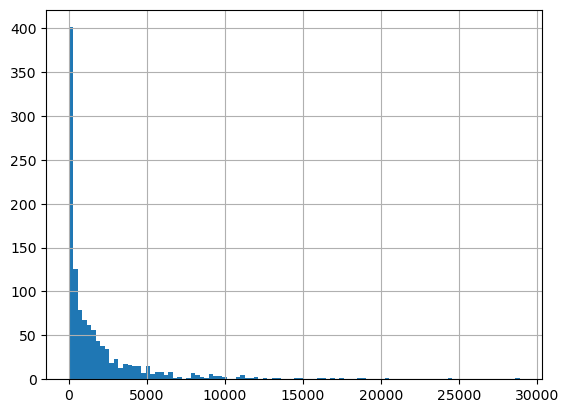

In [ ]:
# display the distribution of the number of different TFs overlapping with CREs
number_of_tfbs = remap2022_CRE_overlap_filtered_df["TF_name"].value_counts().reset_index()
number_of_tfbs
number_of_tfbs["count"].hist(bins=100)

### Identify the non-overlapping TFBS number for each CRE